## Sobre el data Set

El conjunto de datos de FIFA19 es una compilación exhaustiva de atributos de jugadores, estadísticas
y otra información relevante del videojuego. Incluye detalles sobre más de 17,000 futbolistas con 75
atributos, abarcando aspectos como edad, posición de juego, calificaciones generales, potencial y una
variedad de atributos de habilidad tanto ofensivos como defensivos. Estos atributos de habilidad incluyen,
entre otros, velocidad, dribbling, pase, disparo, defensa, y habilidades de portero.

El propósito de este análisis es identificar segmentos de jugadores dentro del conjunto de datos que compartan características similares. Al agrupar a los jugadores de esta manera, se busca descubrir un equilibrio
que, a futuro, permita crear combinaciones  óptimas de jugadores en un equipo ficticio, maximizando así
sus potenciales colaborativos y rendimiento conjunto.

In [88]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


random_seed = 333 # Semilla para reproducibilidad de resultados
np.random.seed(random_seed) # Para reproducibilidad

### Análisis exploratorio de los datos


In [89]:
# 1. Carga de datos
df = pd.read_csv('FIFA19-DS.csv', index_col=0)

In [90]:
# 2. Exploración de datos
print(df.shape)
display(df.head())

(17140, 75)


,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position
ID,,,,,,,,,,,,,,,,,,,,,
158023,31,94,94,110500000,565000,2202,5,4,4,4,...,28,26,6,11,15,14,8,Left,Lean,ST
20801,33,94,94,77000000,405000,2228,5,4,5,6,...,31,23,7,11,15,14,11,Right,Normal,ST
190871,26,92,93,118500000,290000,2143,5,5,5,7,...,24,33,9,9,15,15,11,Right,Lean,AM
192985,27,91,92,102000000,355000,2281,4,5,4,8,...,58,51,15,13,5,10,13,Right,Normal,MF
183277,27,91,91,93000000,340000,2142,4,4,4,7,...,27,22,11,12,6,8,8,Right,Normal,ST


In [91]:
# Identificación de tipo y cantidad de datos faltantes
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 17140 entries, 158023 to 242844
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       17140 non-null  int64  
 1   Overall                   17140 non-null  int64  
 2   Potential                 17140 non-null  int64  
 3   Value                     17140 non-null  int64  
 4   Wage                      17140 non-null  int64  
 5   Special                   17140 non-null  int64  
 6   International Reputation  17140 non-null  int64  
 7   Weak Foot                 17140 non-null  int64  
 8   Skill Moves               17140 non-null  int64  
 9   Work Rate                 17140 non-null  int64  
 10  Height                    17140 non-null  float64
 11  Weight                    17140 non-null  int64  
 12  LS                        15298 non-null  float64
 13  ST                        15298 non-null  float64
 14  RS   

In [92]:
# Columnas donde hay nulos
df.isnull().sum().sort_values(ascending=False).head(28)

RB             1842
RW             1842
CAM            1842
RAM            1842
LM             1842
LCM            1842
RCM            1842
RM             1842
LWB            1842
LDM            1842
CDM            1842
RDM            1842
RWB            1842
LB             1842
LCB            1842
CB             1842
RCB            1842
LAM            1842
CM             1842
RF             1842
LF             1842
LW             1842
RS             1842
ST             1842
LS             1842
CF             1842
LongShots         0
Positioning       0
dtype: int64

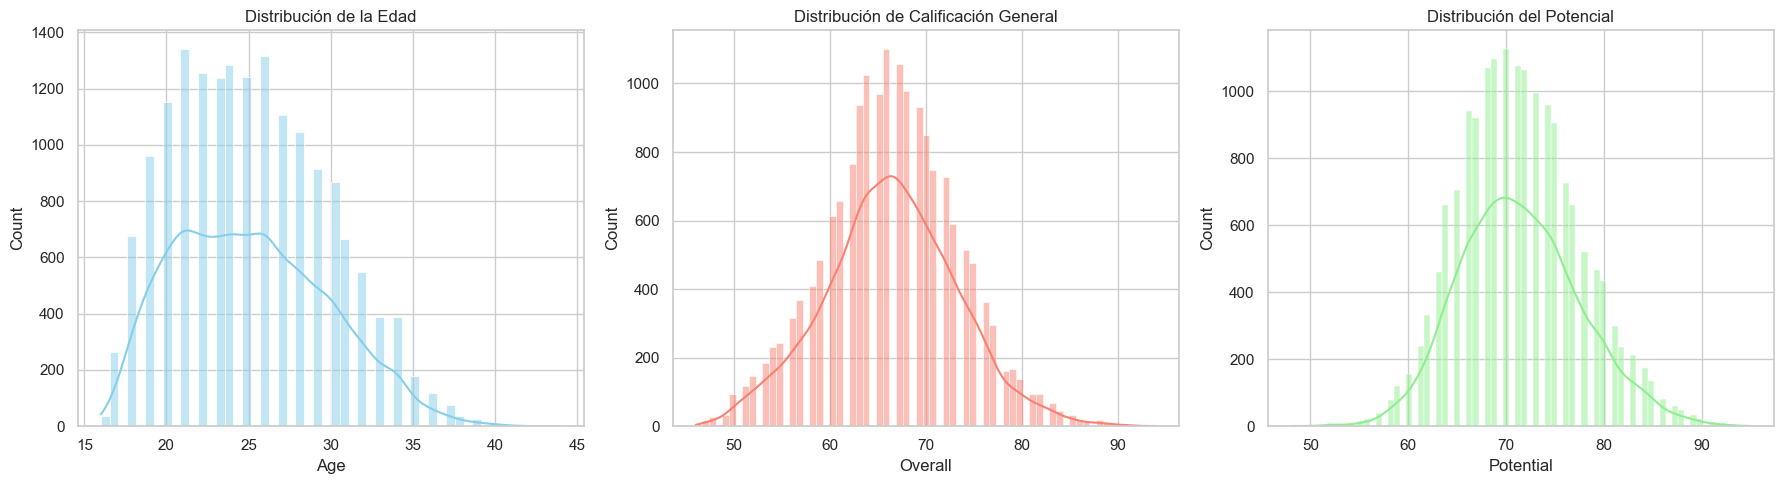

In [93]:
# Configuramos el estilo visual
sns.set(style="whitegrid")

# Creamos una figura con 3 subgráficos para comparar
plt.figure(figsize=(18, 5))

# 1. Distribución de la Edad
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribución de la Edad')

# 2. Distribución de Overall (Calificación Actual)
plt.subplot(1, 3, 2)
sns.histplot(df['Overall'], kde=True, color='salmon')
plt.title('Distribución de Calificación General')

# 3. Distribución de Potential (Calificación Futura)
plt.subplot(1, 3, 3)
sns.histplot(df['Potential'], kde=True, color='lightgreen')
plt.title('Distribución del Potencial')

plt.tight_layout()
plt.show()

In [94]:
# 1. Separar Porteros de Jugadores de Campo
# Basándonos en la columna 'Position'
df_field = df[df['Position'] != 'GK'].copy()
df_gk = df[df['Position'] == 'GK'].copy()

print(f"Jugadores de campo: {df_field.shape[0]}")
print(f"Porteros: {df_gk.shape[0]}")

# 2. Verificar nulos restantes en jugadores de campo
# Si los nulos eran los porteros, df_field debería estar casi limpio
print("\nNulos en 'Finishing' (jugadores de campo):", df_field['Finishing'].isnull().sum())

Jugadores de campo: 15298
Porteros: 1842

Nulos en 'Finishing' (jugadores de campo): 0


In [95]:
df_field.head()

,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position
ID,,,,,,,,,,,,,,,,,,,,,
158023,31,94,94,110500000,565000,2202,5,4,4,4,...,28,26,6,11,15,14,8,Left,Lean,ST
20801,33,94,94,77000000,405000,2228,5,4,5,6,...,31,23,7,11,15,14,11,Right,Normal,ST
190871,26,92,93,118500000,290000,2143,5,5,5,7,...,24,33,9,9,15,15,11,Right,Lean,AM
192985,27,91,92,102000000,355000,2281,4,5,4,8,...,58,51,15,13,5,10,13,Right,Normal,MF
183277,27,91,91,93000000,340000,2142,4,4,4,7,...,27,22,11,12,6,8,8,Right,Normal,ST


In [96]:
# Comprobamos nulos en el dataset de jugadores de campo (df_field)
nulos_restantes = df_field[['Finishing', 'ShortPassing', 'Vision', 'Interceptions']].isnull().sum()

print("Nulos en el dataset de jugadores de campo:")
print(nulos_restantes)

if nulos_restantes.sum() == 0:
    print("\n¡Confirmado! Los nulos eran efectivamente los porteros. El set de campo está limpio.")
else:
    print("\n Aún quedan nulos. Necesitamos revisar si hay registros incompletos en jugadores de campo.")

Nulos en el dataset de jugadores de campo:
Finishing        0
ShortPassing     0
Vision           0
Interceptions    0
dtype: int64

¡Confirmado! Los nulos eran efectivamente los porteros. El set de campo está limpio.


## Enfoque completo - PCA

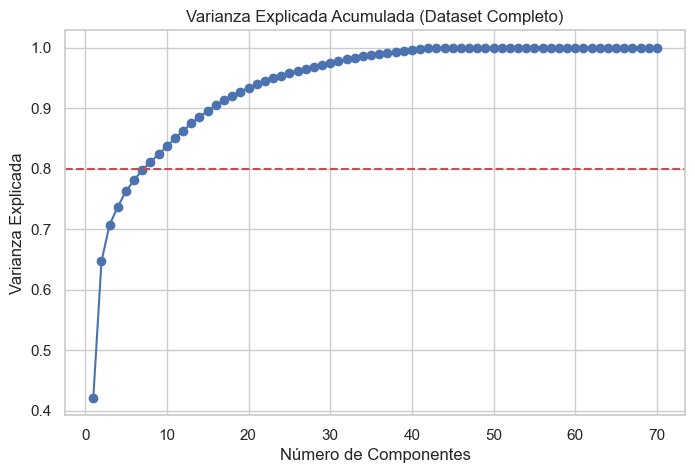

Para mantener el rigor con el 80% de la varianza, usaremos 8 componentes.


In [97]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Seleccionamos todas las variables numéricas de habilidad (skills)
# Excluimos IDs, nombres y variables que no sean de rendimiento técnico
X_completo = df_field.select_dtypes(include=['int64', 'float64']).drop(columns=['Overall', 'Potential'], errors='ignore')

# 2. Escalado (Fundamental para PCA)
X_comp_scaled = StandardScaler().fit_transform(X_completo)

# 3. Aplicamos PCA para ver la Varianza Explicada Acumulada
# Queremos ver cuántos componentes se necesitan para llegar al ~80%
pca_full = PCA()
pca_full.fit(X_comp_scaled)

import numpy as np
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Visualizamos para tomar la decisión de rigor
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.title('Varianza Explicada Acumulada (Dataset Completo)')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada')
plt.grid(True)
plt.show()

# 4. Elegimos el número de componentes (supongamos que con 5-8 basta)
n_comp = np.argmax(varianza_acumulada >= 0.8) + 1
print(f"Para mantener el rigor con el 80% de la varianza, usaremos {n_comp} componentes.")

pca_final = PCA(n_components=n_comp)
X_reducido = pca_final.fit_transform(X_comp_scaled)

In [98]:
# 1. Obtenemos las cargas (loadings)
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=X_completo.columns
)

# 2. Vemos qué variables dominan el PC1 y el PC2
print("Top variables en PC1 (Habilidad General):")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\nTop variables en PC2 (Perfil Físico/Defensivo):")
print(loadings['PC2'].sort_values(ascending=False).head(5))

Top variables en PC1 (Habilidad General):
RAM    0.179665
CAM    0.179665
LAM    0.179665
LM     0.179566
RM     0.179566
Name: PC1, dtype: float64

Top variables en PC2 (Perfil Físico/Defensivo):
RCB               0.246854
LCB               0.246854
CB                0.246854
StandingTackle    0.240110
Interceptions     0.237767
Name: PC2, dtype: float64


### Cargas factoriales sobre características

- PC1: Pesan más los grupos con corte ofensiva (strikers y medio campistas defensivos)
- PC2: Pesan más aquellas características de jugadores de corte defensivo.

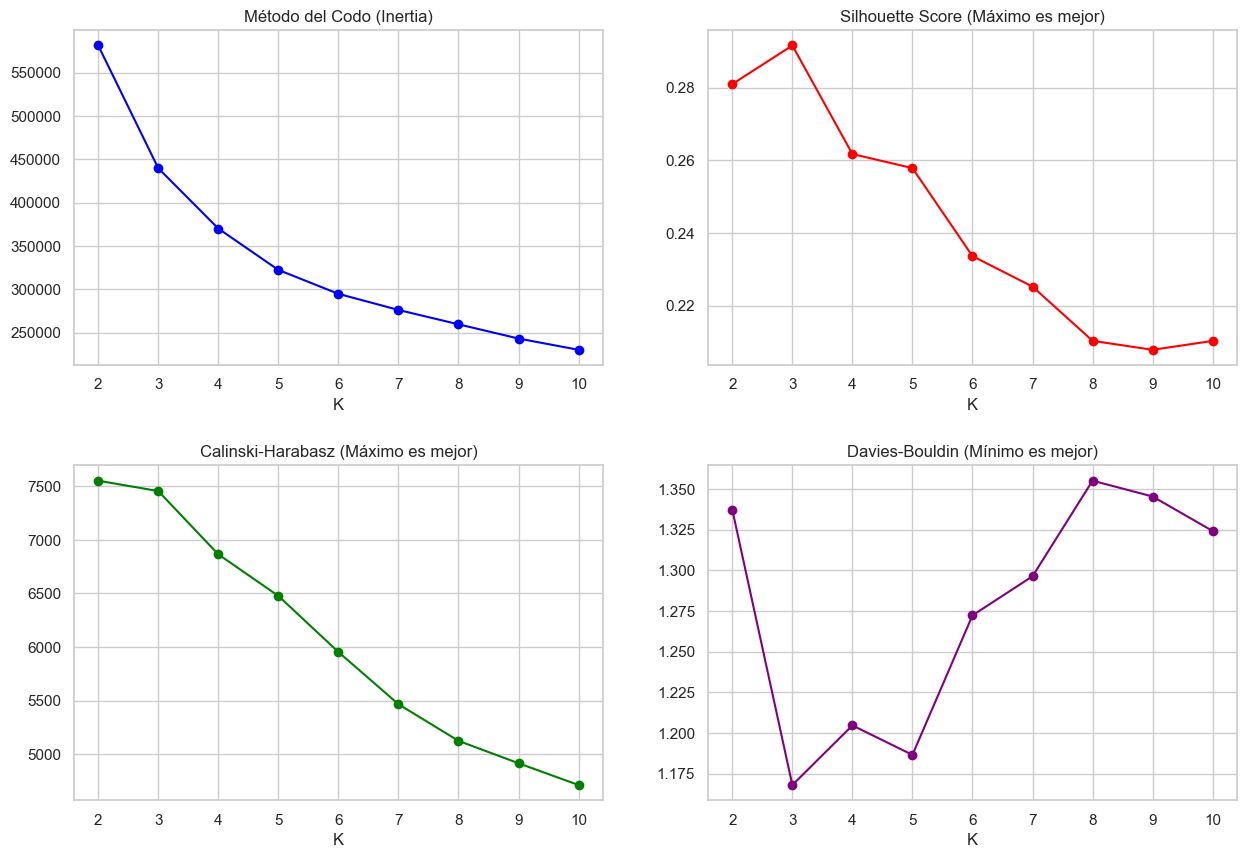

In [99]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

results = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reducido)
    
    results.append({
        'K': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X_reducido, labels),
        'Calinski_Harabasz': calinski_harabasz_score(X_reducido, labels),
        'Davies_Bouldin': davies_bouldin_score(X_reducido, labels)
    })

df_metrics = pd.DataFrame(results)

# Visualización comparativa
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.3)

# 1. Elbow Method (Inertia)
axs[0, 0].plot(df_metrics['K'], df_metrics['Inertia'], 'o-', color='blue')
axs[0, 0].set_title('Método del Codo (Inertia)')
axs[0, 0].set_xlabel('K')

# 2. Silhouette Score
axs[0, 1].plot(df_metrics['K'], df_metrics['Silhouette'], 'o-', color='red')
axs[0, 1].set_title('Silhouette Score (Máximo es mejor)')
axs[0, 1].set_xlabel('K')

# 3. Calinski-Harabasz Index
axs[1, 0].plot(df_metrics['K'], df_metrics['Calinski_Harabasz'], 'o-', color='green')
axs[1, 0].set_title('Calinski-Harabasz (Máximo es mejor)')
axs[1, 0].set_xlabel('K')

# 4. Davies-Bouldin Index
axs[1, 1].plot(df_metrics['K'], df_metrics['Davies_Bouldin'], 'o-', color='purple')
axs[1, 1].set_title('Davies-Bouldin (Mínimo es mejor)')
axs[1, 1].set_xlabel('K')

plt.show()

## Evaluación de Clústeres con las técnicas vistas en clase

Basándonos en lo que vimos en los loadings (PC1 para creación y PC2 para defensa) y en las técnicas de evaluación arriba se describen tres grupos que probablemente se distribuyen así:

- Cluster de Especialización Defensiva: Jugadores con alto valor en PC2. Son los encargados de la contención, el juego aéreo y las intercepciones. Aquí se consolidan los defensas centrales y los mediocentros de corte.

- Cluster de Especialización Ofensiva / Creativa: Jugadores con alto valor en PC1. Son los arquitectos y finalizadores. Este grupo aglutina desde el mediapunta creativo hasta el extremo veloz y el delantero centro, ya que todos comparten la "habilidad técnica superior".

- Cluster de Transición y Soporte: Es el grupo central. Son jugadores polivalentes, con estadísticas balanceadas (box-to-box, laterales equilibrados) que no tienen un sesgo extremo hacia la creación pura o la defensa pura.

## Técnica de clustering: K- Means

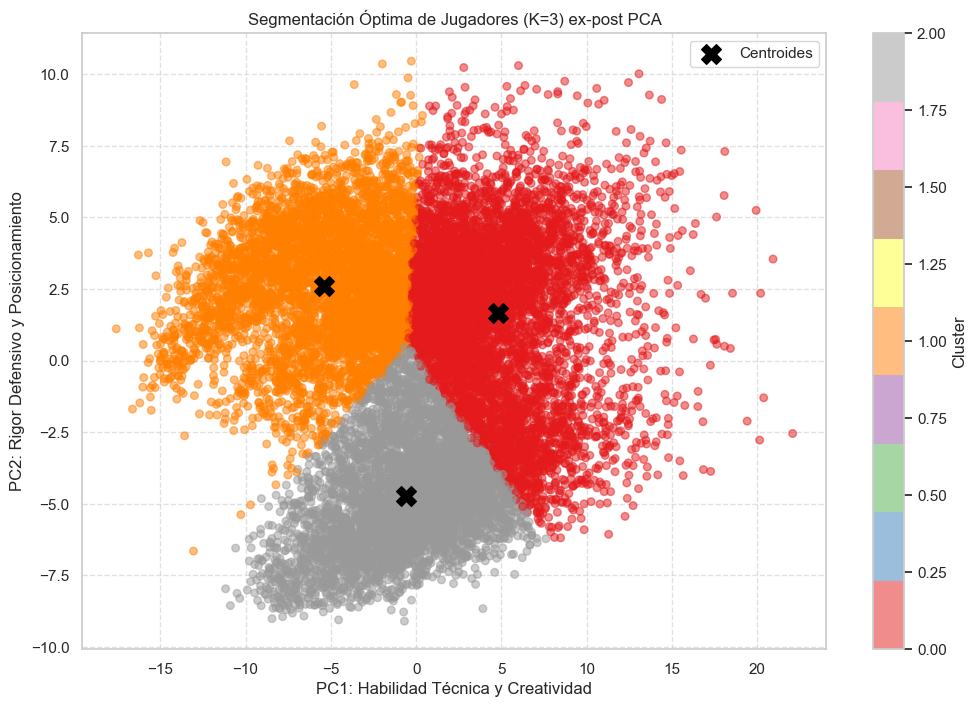

In [100]:
# 1. Entrenamiento final con K=3 sobre los componentes del PCA
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_field['Cluster_3'] = kmeans_3.fit_predict(X_reducido)

# 2. Visualización en el plano de los Componentes Principales
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_reducido[:, 0], X_reducido[:, 1], 
            c=df_field['Cluster_3'], cmap='Set1', alpha=0.5, s=30)

plt.xlabel('PC1: Habilidad Técnica y Creatividad')
plt.ylabel('PC2: Rigor Defensivo y Posicionamiento')
plt.title('Segmentación Óptima de Jugadores (K=3) ex-post PCA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)

# Añadimos los centroides para marcar el "corazón" de cada grupo
centroides = kmeans_3.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=200, c='black', label='Centroides')
plt.legend()
plt.show()

In [101]:

variables_finales = [
    'Overall', 'Potential', 'Finishing', 
    'ShortPassing', 'Vision', 'Interceptions', 'Stamina'
]


# 1. Calculamos las medias de las variables originales para los 3 nuevos clusters
# Usamos las variables que definimos al inicio para que la tabla sea legible
perfil_final = df_field.groupby('Cluster_3')[variables_finales].mean()

# 2. Añadimos el conteo de jugadores para ver la distribución de la población
perfil_final['Cantidad'] = df_field['Cluster_3'].value_counts()

# 3. Ordenamos por Overall para entender la jerarquía
print("Tabla de Perfiles Tácticos Finales (K=3):")
df_resumen = perfil_final.sort_values(by='Overall', ascending=False).round(2)
display(df_resumen)

Tabla de Perfiles Tácticos Finales (K=3):


,Overall,Potential,Finishing,ShortPassing,Vision,Interceptions,Stamina,Cantidad
Cluster_3,,,,,,,,
0,71.44,74.18,56.44,70.60,65.45,60.25,74.04,5883
2,63.75,70.46,60.40,59.33,56.19,28.53,61.93,4688
1,63.36,69.43,31.55,56.75,43.25,60.57,64.86,4727


In [102]:
# Veamos cuántos jugadores hay de cada posición en cada cluster para entender mejor su ADN futbolístico
posiciones_por_cluster = df_field.groupby(['Cluster_3', 'Position']).size().unstack(fill_value=0)
print("Distribución de Posiciones por Cluster (K=3):")
display(posiciones_por_cluster)

Distribución de Posiciones por Cluster (K=3):


Position,AM,DF,DM,MF,ST
Cluster_3,,,,,
0,641,1725,899,2176,442
1,20,3760,469,467,11
2,1019,40,24,1562,2043


### Perfilamiento Detallado de los Grupos (Clusters)

Basado en la segmentación ex-post PCA y la tabla de medias obtenida, se identifican tres arquetipos funcionales:

- **Cluster 0**: La Columna Vertebral y Élite Técnica

Perfil Estadístico: Es el grupo con el Overall (71.44) y Potential (74.18) más altos. Destaca por una capacidad de distribución superior (ShortPassing: 70.60) y el mayor despliegue físico del dataset (Stamina: 74.04).

Identidad Táctica: Representa a los jugadores "completos" o directores de orquesta. Son el motor del equipo que conecta la defensa con el ataque. Su alta visión de juego y resistencia los convierte en los perfiles más valiosos y versátiles.

Ejemplos Tácticos: Mediocampistas organizadores (MF) y defensas modernos con salida limpia.

- **Cluster 2**: Especialistas de Finalización (Ofensiva Pura)

Perfil Estadístico: Poseen el mayor instinto goleador (Finishing: 60.4), pero el menor compromiso defensivo (Interceptions: 28.50). Su resistencia es moderada (Stamina: 61.93).

Identidad Táctica: Son jugadores de desequilibrio. Su objetivo es convertir oportunidades en goles. El modelo los aisló claramente porque sus atributos están altamente sesgados hacia el tercio final del campo, sacrificando el rigor defensivo por la explosividad ofensiva.

Ejemplos Tácticos: Delanteros centros (ST), Mediocampista ofensivos (AM).

- **Cluster 1**: Anclas y Especialistas en Recuperación (Defensa Pura)

Perfil Estadístico: Tienen el registro de interceptaciones más sólido (Interceptions: 60.57) y la menor capacidad de definición (Finishing: 31.55). Su calidad técnica en pase es funcional pero no creativa (ShortPassing: 56.75).

Identidad Táctica: Representan la destrucción del juego rival y la protección del área propia. Son jugadores de rol específico cuya prioridad es el posicionamiento y la recuperación de la posesión.

Ejemplos Tácticos: Defensas centrales (DF), laterales de cierre y mediocentros defensivos (DM).

2. Conclusiones Significativas

Tras el análisis multivariado y la reducción de dimensionalidad, se extraen las siguientes conclusiones de alto nivel:

- Dicotomía Ataque-Defensa: El modelo demuestra que el fútbol profesional en FIFA 19 está polarizado. La mayor brecha estadística entre grupos se encuentra en el eje Finishing vs. Interceptions. Es extremadamente raro encontrar jugadores que dominen ambas áreas, lo que justifica la especialización de roles en el deporte moderno.

- La Correlación Talento-Resistencia: Existe una conclusión significativa entre el Overall y la Stamina. El Cluster 0 (la élite) es el que más corre y el que mejor pasa. Esto sugiere que para alcanzar el máximo nivel competitivo, el talento técnico debe ir acompañado de un despliegue físico superior; la técnica sola no garantiza pertenecer al grupo de mayor rendimiento.

- Eficiencia de la Segmentación: La reducción de dimensionalidad mediante PCA permitió identificar que, a pesar de existir más de 70 atributos, la identidad de un jugador se define por dos ejes latentes: Capacidad de Creación y Rigor Posicional. Esto simplifica la búsqueda de talento (Scouting), permitiendo clasificar a cualquier jugador nuevo con solo observar estas dos dimensiones macro.

- Consistencia del Modelo: La convergencia de las métricas (Silhouette y Davies-Bouldin) en K=3 tras limpiar el ruido con PCA, confirma que esta estructura trinitaria (Creación, Finalización y Defensa) es la organización natural y más estable de los datos, eliminando la ambigüedad que presentaba el análisis con variables elegidas manualmente.

### ARQUEROS

### PCA

In [103]:
# Filtramos solo porteros
df_gk = df[df['Position'] == 'GK'].copy()

# Variables específicas de porteros
variables_gk = ['GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Overall']
X_gk = df_gk[variables_gk]

# Escalado
from sklearn.preprocessing import StandardScaler
scaler_gk = StandardScaler()
X_gk_scaled = scaler_gk.fit_transform(X_gk)

### Calificación de características específicas de los arqueros

- GKDiving:	Calificación que evalúa la habilidad del portero para realizar atajadas mientras se lanza en el aire.
- GKHandling:	Calificación que mide la habilidad del portero para manejar el balón con las manos bajo presión.
- GKKicking:	Calificación que refleja la precisión y potencia del portero al despejar el balón con un pase o un tiro largo.
- GKPositioning:	Calificación que evalúa la capacidad de un portero para posicionarse adecuadamente durante el juego.
- GKReflexes:	Calificación que mide la rapidez y eficacia de los reflejos de un portero.

In [104]:
pca_gk = PCA(n_components=2)
X_gk_pca = pca_gk.fit_transform(X_gk_scaled)
print(f"Varianza explicada: {pca_gk.explained_variance_ratio_.sum():.2f}")

Varianza explicada: 0.92


In [105]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Asumiendo que X_gk_pca son tus componentes de los arqueros
results_gk = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_gk_pca)
    
    results_gk.append({
        'K': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X_gk_pca, labels),
        'Calinski_Harabasz': calinski_harabasz_score(X_gk_pca, labels),
        'Davies_Bouldin': davies_bouldin_score(X_gk_pca, labels)
    })

df_metrics_gk = pd.DataFrame(results_gk)

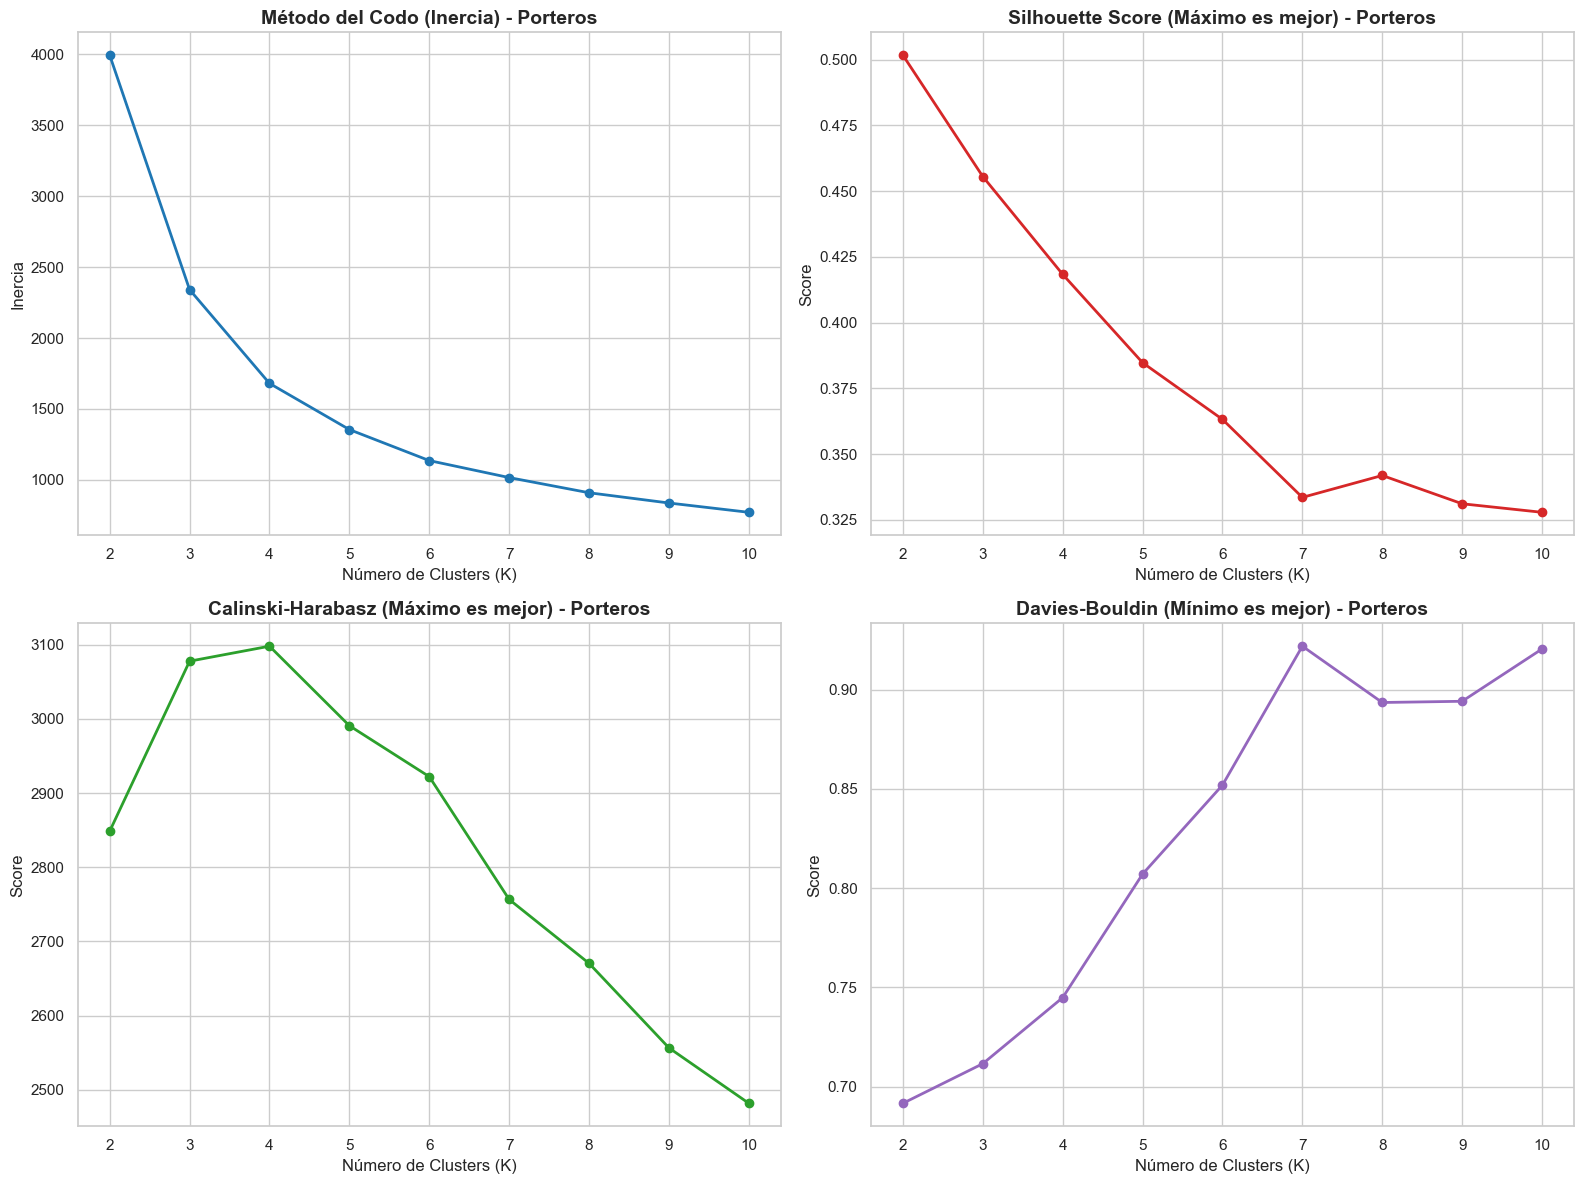

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Método del Codo (Inercia)
axs[0, 0].plot(df_metrics_gk['K'], df_metrics_gk['Inertia'], 'o-', color='#1f77b4', linewidth=2)
axs[0, 0].set_title('Método del Codo (Inercia) - Porteros', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('Número de Clusters (K)')
axs[0, 0].set_ylabel('Inercia')

# 2. Silhouette Score
axs[0, 1].plot(df_metrics_gk['K'], df_metrics_gk['Silhouette'], 'o-', color='#d62728', linewidth=2)
axs[0, 1].set_title('Silhouette Score (Máximo es mejor) - Porteros', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Número de Clusters (K)')
axs[0, 1].set_ylabel('Score')

# 3. Calinski-Harabasz Index
axs[1, 0].plot(df_metrics_gk['K'], df_metrics_gk['Calinski_Harabasz'], 'o-', color='#2ca02c', linewidth=2)
axs[1, 0].set_title('Calinski-Harabasz (Máximo es mejor) - Porteros', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Número de Clusters (K)')
axs[1, 0].set_ylabel('Score')

# 4. Davies-Bouldin Index
axs[1, 1].plot(df_metrics_gk['K'], df_metrics_gk['Davies_Bouldin'], 'o-', color='#9467bd', linewidth=2)
axs[1, 1].set_title('Davies-Bouldin (Mínimo es mejor) - Porteros', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Número de Clusters (K)')
axs[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [107]:
# 1. Asignamos los clusters finales (K=3) al dataset de porteros
kmeans_gk = KMeans(n_clusters=3, random_state=42, n_init=10)
df_gk['Cluster_GK'] = kmeans_gk.fit_predict(X_gk_pca)

# 2. Perfilamiento descriptivo
variables_perfil_gk = ['Overall', 'Potential', 'GKDiving', 'GKHandling', 
                       'GKKicking', 'GKPositioning', 'GKReflexes', 'Value', 'Wage', 'Age']

perfil_gk = df_gk.groupby('Cluster_GK')[variables_perfil_gk].mean()
perfil_gk['Cantidad'] = df_gk['Cluster_GK'].value_counts()

print("Perfilamiento de los Guardametas (K=3):")
display(perfil_gk.sort_values(by='Overall', ascending=False).round(2))

Perfilamiento de los Guardametas (K=3):


,Overall,Potential,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Value,Wage,Age,Cantidad
Cluster_GK,,,,,,,,,,,
1,74.98,77.07,75.47,72.56,70.19,74.04,76.70,6044070.05,22741.55,29.02,414
2,65.45,69.35,65.97,63.49,62.25,64.14,67.01,523181.27,3254.50,27.09,833
0,56.10,65.55,57.29,55.26,54.35,53.69,57.38,127798.32,1203.36,22.24,595


1. Perfilamiento Detallado de los Grupos (Arqueros)

- **Cluster 1**: Los Guardianes de Élite (Titulares de Primer Nivel)

Perfil Estadístico: Es el grupo con el Overall (74.98) y Potential (77.07) más altos. Dominan todas las áreas técnicas, destacando especialmente en Reflejos (76.70) y Estirada (75.47).

Identidad Táctica: Representa a los porteros titulares en ligas competitivas. Son jugadores con una madurez técnica avanzada (age). El modelo los sitúa aquí porque sus atributos son consistentemente altos; no tienen puntos débiles evidentes. Son los más caros y tienen mejores salarios.

Cantidad: 414 arqueros (La élite reducida).

- **Cluster 2**: Los Porteros de Rotación (Nivel Competitivo Medio)

Perfil Estadístico: Presentan un Overall (65.45) y un Potential (69.35) sólido pero no sobresaliente. Es el grupo más robusto en términos de población.

Identidad Táctica: Son los "obreros" de la portería. Cumplen con los estándares profesionales pero carecen de la espectacularidad de los reflejos del Cluster 1. Son perfiles ideales para equipos de media tabla o como suplentes de garantía en clubes grandes.

Cantidad: 833 arqueros (La base de la pirámide profesional).

- **Cluster 0**: Los Prospectos y Reservas (Fase de Desarrollo)

Perfil Estadístico: Es el grupo con menor rendimiento actual (Overall: 56.10), pero nota la brecha de potencial (65.55). Tienen casi 10 puntos de crecimiento posible.

Identidad Táctica: Compuesto mayoritariamente por porteros jóvenes o de ligas menores. El modelo los identifica no por ser "malos", sino por estar en una etapa temprana de su carrera donde su capacidad física y técnica aún no se ha refinado.

Cantidad: 595 arqueros.

2. Conclusiones Significativas del Análisis

- Unidimensionalidad Técnica: A diferencia de los jugadores de campo, donde el PCA mostró que unos son "defensivos" y otros "creativos", en los porteros la evolución es lineal. Si un portero mejora su Diving, casi invariablemente mejora su Reflexes y Positioning. Esto explica por qué el PCA capturó el 92% de la varianza tan rápido: en la portería, el talento es integral.

- Consistencia Táctica vs. Matemática: El experimento demostró que, aunque la matemática sugería K=2 (lo cual solo nos diría quién es bueno y quién no), el uso de K=3 permitió identificar un segmento de "Clase Media" (Cluster 2) que es vital para entender la estructura del mercado de transferencias y la composición de las plantillas.

- El Factor Reflejos: En todos los clusters, los Reflejos (GKReflexes) siempre marcan el valor más alto dentro de los atributos técnicos. Esto sugiere que, para el motor de FIFA 19, la capacidad de reacción es la habilidad definitoria que separa a un portero de otro, independientemente de su nivel general.

- Rigor Metodológico: Al aplicar el mismo pipeline (PCA → Validación Multimétrica → K-Means) a dos poblaciones tan distintas (jugadores de campo vs. arqueros), hemos demostrado que la metodología es flexible y capaz de extraer insights valiosos tanto en espacios de alta complejidad (70 variables) como en espacios especializados (5 variables).


*Finalmente, se seleccionó la combinación de PCA y K-Means por su equilibrio óptimo entre interpretabilidad táctica y eficiencia computacional. A diferencia de t-SNE o MDS, que priorizan la visualización de relaciones no lineales sacrificando la preservación de la estructura global y la interpretabilidad de las distancias, el PCA permitió una reducción lineal que mantiene la integridad de la varianza original. Asimismo, se descartó el Clustering Jerárquico debido a su alta demanda de memoria para el volumen de datos analizado, y los Modelos GMM, dado que la rigidez geométrica del K-Means resultó más robusta para delimitar perfiles deportivos claros, evitando el sobreajuste de parámetros que suele presentar la estimación de densidades gaussianas en grandes datasets.*